# Session X — Make the training loop tell the truth

This notebook uses a two-layer causal Transformer and actual optimizer steps. It reports every material tensor in one step, checks a real model weight by finite differences, demonstrates unequal-token accumulation, records a gradient warning before its loss consequence, computes an explicit MFU proxy, and derives the bits of `0.1`.

All experiments are deterministic except wall-clock timing. The generated JSON and plots are also committed for review.

## Setup

In [1]:
import math, time
from pathlib import Path
import matplotlib.pyplot as plt
import torch

from truth_loop import (
    Config, TinyLM, causal_ce, describe_0_1, estimate_mfu,
    trace_training_step, train_accum_comparison,
    train_with_grad_norm_log, verify_grad_hand,
)

torch.manual_seed(0)
torch.set_num_threads(2)
ART, FIG = Path("artifacts"), Path("figures")
ART.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)
print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available(), "| threads:", torch.get_num_threads())

PyTorch: 2.13.0+cpu | CUDA: False | threads: 2


## 1. Every tensor shape in one training step

Notation: `B` batch examples, `T` token positions, `C` embedding channels, `H` attention heads, `D=C/H` channels per head, and `V` vocabulary size. The helper below performs the full forward pass, next-token cross entropy, backward pass, and prints one explanation per tensor (including every parameter and parameter gradient).

In [2]:
cfg = Config(vocab_size=50, n_embd=64, n_layer=2, n_head=2, block_size=32)
model = TinyLM(cfg)
tokens = torch.randint(0, cfg.vocab_size, (2, 24))
shape_rows = trace_training_step(model, tokens)
print(f"\nReported {len(shape_rows)} tensors; valid CE targets = 2*(24-1) = 46.")

param.tok_emb.weight         (50, 64)           trainable parameter dimensions
param.pos_emb.weight         (32, 64)           trainable parameter dimensions
param.blocks.0.ln1.weight    (64,)              trainable parameter dimensions
param.blocks.0.ln1.bias      (64,)              trainable parameter dimensions
param.blocks.0.qkv.weight    (192, 64)          trainable parameter dimensions
param.blocks.0.proj.weight   (64, 64)           trainable parameter dimensions
param.blocks.0.ln2.weight    (64,)              trainable parameter dimensions
param.blocks.0.ln2.bias      (64,)              trainable parameter dimensions
param.blocks.0.mlp.0.weight  (256, 64)          trainable parameter dimensions
param.blocks.0.mlp.0.bias    (256,)             trainable parameter dimensions
param.blocks.0.mlp.2.weight  (64, 256)          trainable parameter dimensions
param.blocks.0.mlp.2.bias    (64,)              trainable parameter dimensions
param.blocks.1.ln1.weight    (64,)              trai

## 2. Verify one gradient by hand

For the real model parameter `blocks.0.mlp.0.weight[0,0]`, `backward()` gives \(g=\\partial L/\\partial w\). I nudge only that scalar in FP64:

\[
g_{FD}=\\frac{L(w+\\epsilon)-L(w-\\epsilon)}{2\\epsilon}.
\]

FP64 and a central difference reduce numerical cancellation. The toy scalar is included only to show the symbolic derivative; the graded comparison is the TinyLM cross-entropy weight.

In [3]:
vg = verify_grad_hand(eps=1e-3)
d = vg["tinylm_ce"]
print(f"parameter       : {d['param']}")
print(f"w, epsilon      : {d['original_weight']:.12f}, {d['eps']}")
print(f"L(w + epsilon)  : {d['loss_plus']:.12f}")
print(f"L(w - epsilon)  : {d['loss_minus']:.12f}")
print(f"finite difference: {d['numerical']:.12f}")
print(f"backward()       : {d['analytic']:.12f}")
print(f"absolute error   : {d['abs_err']:.3e}")
print(f"relative error   : {d['rel_err']:.3e}")
assert d["rel_err"] < 1e-3
print("\nAgreement to several decimals: the implemented loss and autograd derivative are consistent.")

parameter       : blocks.0.mlp.0.weight[0,0]
w, epsilon      : 0.036201652139, 0.001
L(w + epsilon)  : 3.479381625957
L(w - epsilon)  : 3.479399030455
finite difference: -0.008702248968
backward()       : -0.008702265595
absolute error   : 1.663e-08
relative error   : 1.911e-06

Agreement to several decimals: the implemented loss and autograd derivative are consistent.


## 3. Break gradient accumulation on purpose

Lengths `[16,16,48,48]` contribute `[15,15,47,47]` next-token losses.

* Wrong: \(\frac14\sum_i \bar L_i\), so every microbatch gets 25%.
* Correct: \(\\frac{\sum_i \sum_j L_{ij}}{\sum_i n_i}\), so weights are `[12.1%,12.1%,37.9%,37.9%]`.

Short sequences use a `+1` token pattern while long sequences use `-1`, making the weighting error visible rather than relying on sampling noise. Both cloned models are evaluated with the same token-weighted metric. Each path calls `backward()` once per microbatch, retains accumulated `.grad` values, and calls `optimizer.step()` exactly once.

final common token-weighted eval:
  wrong-trained model : 0.2445
  correct-trained model: 0.1635
mean objective gap on identical model/data: 0.1001


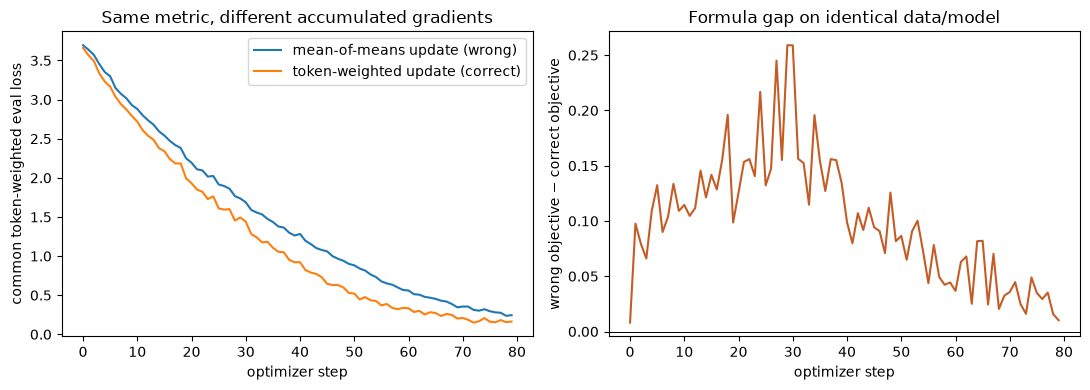

In [4]:
hist = train_accum_comparison(steps=80, seed=0)
print("final common token-weighted eval:")
print(f"  wrong-trained model : {hist['eval_wrong_model'][-1]:.4f}")
print(f"  correct-trained model: {hist['eval_right_model'][-1]:.4f}")
print(f"mean objective gap on identical model/data: "
      f"{sum(hist['objective_gap_initial_model'])/len(hist['step']):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist["step"], hist["eval_wrong_model"], label="mean-of-means update (wrong)")
ax[0].plot(hist["step"], hist["eval_right_model"], label="token-weighted update (correct)")
ax[0].set(xlabel="optimizer step", ylabel="common token-weighted eval loss",
          title="Same metric, different accumulated gradients")
ax[0].legend()
ax[1].plot(hist["step"], hist["objective_gap_initial_model"], color="#c45c26")
ax[1].axhline(0, color="black", lw=.7)
ax[1].set(xlabel="optimizer step", ylabel="wrong objective − correct objective",
          title="Formula gap on identical data/model")
fig.tight_layout(); fig.savefig(FIG/"accum_gap.png", dpi=150); plt.show()

## 4. Log gradient norm; find where it moves before loss

The probe loss is measured **before** each update. At step 45 I deliberately simulate a loss-scaling bug: the raw loss stays unchanged, but the backward objective is multiplied by 80 and clipping is disabled. This controlled intervention isolates the diagnostic timing: gradient norm warns at step \(s\); the resulting parameter damage cannot appear in pre-update probe loss until \(s+1\).

grad norm, steps 44 -> 45: 1.1648 -> 92.1840
pre-update probe loss, steps 44 -> 45 -> 46: 2.5328 -> 2.5099 -> 3.0494
The raw/probe loss was measured before the update. A controlled 80x backward-scale bug made ||g|| jump at step s; its effect on probe loss could only be observed at step s+1.


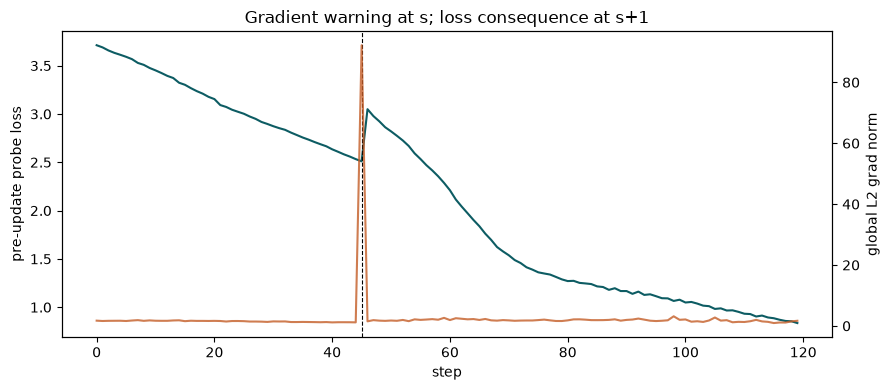

In [5]:
gn = train_with_grad_norm_log(steps=120, spike_at=45)
f = gn["finding"]
print(f"grad norm, steps 44 -> 45: {f['grad_norm_before']:.4f} -> {f['grad_norm_at_warning']:.4f}")
print("pre-update probe loss, steps 44 -> 45 -> 46: "
      f"{f['probe_loss_before']:.4f} -> {f['probe_loss_at_warning_pre_update']:.4f} "
      f"-> {f['probe_loss_next_step']:.4f}")
print(f["note"])

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(gn["step"], gn["probe_loss_pre_update"], color="#0d5c63")
ax1.set(xlabel="step", ylabel="pre-update probe loss")
ax2 = ax1.twinx()
ax2.plot(gn["step"], gn["grad_norm"], color="#c45c26", alpha=.8)
ax2.set_ylabel("global L2 grad norm")
ax1.axvline(45, color="black", ls="--", lw=.8)
ax1.set_title("Gradient warning at s; loss consequence at s+1")
fig.tight_layout(); fig.savefig(FIG/"grad_norm_vs_loss.png", dpi=150); plt.show()

## 5. Compute MFU honestly

I use \(F \\approx tokens(6N + 12LCT)\): `6N` for forward/backward parameter operations plus sequence-dependent attention matmuls. This CPU-only VM exposes two physical 2.5 GHz Cascade Lake cores. Its nominal FP32 ceiling is:

`2 cores × 2 AVX-512 FMA units × 16 lanes × 2 FLOP/FMA × 2.5 GHz = 0.320 TFLOP/s`.

This is an architectural upper bound (AVX downclock and VM scheduling make it uncertain), so the result is explicitly an **MFU proxy**, not an H100 MFU claim.

In [6]:
cfg_m = Config(vocab_size=64, n_embd=128, n_layer=4, n_head=4, block_size=128)
m = TinyLM(cfg_m)
opt = torch.optim.AdamW(m.parameters(), lr=1e-3)
B, T, steps = 8, 64, 20
x = torch.randint(0, cfg_m.vocab_size, (B, T))
for _ in range(3):
    opt.zero_grad(set_to_none=True); loss, _ = causal_ce(m(x)["logits"], x)
    loss.backward(); opt.step()
t0 = time.perf_counter()
for _ in range(steps):
    opt.zero_grad(set_to_none=True); loss, _ = causal_ce(m(x)["logits"], x)
    loss.backward(); opt.step()
wall = time.perf_counter() - t0
tokens_done = steps * B * (T-1)
mfu = estimate_mfu(m.n_params(), tokens_done, wall, 0.320,
                   n_layer=cfg_m.n_layer, n_embd=cfg_m.n_embd, seq_len=T)
print(f"N={m.n_params():,}, tokens={tokens_done:,}, wall={wall:.3f}s")
print(f"model FLOPs={mfu['approx_flops']/1e9:.2f} GFLOP")
print(f"achieved={mfu['achieved_tflops']:.4f} TFLOP/s")
print(f"MFU proxy={mfu['mfu_pct']:.2f}% of nominal CPU FP32 peak")
print("Distance to 40%: tiny GEMMs, eager/Python overhead, unfused attention/CE, "
      "Adam memory traffic, and VM scheduling. Peak-frequency uncertainty and the "
      "approximate FLOP model are also error bars on this number.")

N=815,872, tokens=10,080, wall=0.652s
model FLOPs=53.31 GFLOP
achieved=0.0818 TFLOP/s
MFU proxy=25.56% of nominal CPU FP32 peak
Distance to 40%: tiny GEMMs, eager/Python overhead, unfused attention/CE, Adam memory traffic, and VM scheduling. Peak-frequency uncertainty and the approximate FLOP model are also error bars on this number.


## 6. Write `0.1` in FP32, BF16, and FP8 E4M3

Binary `0.1 = 1.100110011... × 2^-4`; `1001` repeats forever, so every finite format rounds it. Biases are 127 for FP32/BF16 and 7 for E4M3. Conversion uses round-to-nearest-even.

In [7]:
bits = describe_0_1()
for name, d in bits.items():
    grouped = f"{d['sign']} | {d['exponent_bits']} | {d['mantissa_bits']}"
    print(f"{name:9s}: {grouped:38s} ({d['bits']}, {d['hex']})")
    print(f"           exponent={d['exponent_unbiased']}, value={d['approx_value']:.12f}")

print("""
FP32: 0 | 01111011 | 10011001100110011001101 = 0.100000001490
BF16: 0 | 01111011 | 1001101                 = 0.100097656250
E4M3: 0 | 0011     | 101                     = 0.101562500000

Choice: BF16 for matrix compute, with FP32 master weights and optimizer state.
It keeps FP32's exponent range while halving storage/bandwidth. E4M3 needs dynamic
scaling and FP8-aware kernels; its 1.5625% error on 0.1 shows why I would not use
raw FP8 as an unsupported default.
""")

fp32     : 0 | 01111011 | 10011001100110011001101 (00111101110011001100110011001101, 0x3DCCCCCD)
           exponent=-4, value=0.100000001490
bf16     : 0 | 01111011 | 1001101                 (0011110111001101, 0x3DCD)
           exponent=-4, value=0.100097656250
fp8_e4m3 : 0 | 0011 | 101                         (00011101, 0x1D)
           exponent=-4, value=0.101562500000

FP32: 0 | 01111011 | 10011001100110011001101 = 0.100000001490
BF16: 0 | 01111011 | 1001101                 = 0.100097656250
E4M3: 0 | 0011     | 101                     = 0.101562500000

Choice: BF16 for matrix compute, with FP32 master weights and optimizer state.
It keeps FP32's exponent range while halving storage/bandwidth. E4M3 needs dynamic
scaling and FP8-aware kernels; its 1.5625% error on 0.1 shows why I would not use
raw FP8 as an unsupported default.



## Reproduce

Run `python run_session_x.py` to regenerate `artifacts/results.json` and both figures. The README records the measured values from the checked-in run.